# e03 — English eval — `label_smoothing_eps01_2ep`

**Model run id:** `label_smoothing_eps01_2ep` (must match `MODEL_CHECKPOINT_CANDIDATES` in `e07_english_eval_common.py`).

**Shared code:** `e07_english_eval_common.py` in this directory (`run_english_eval_pipeline`).

**When you execute this notebook** it will load the checkpoint, run inference on English CSVs, and write:

- `notebooks/results/english_eval/label_smoothing_eps01_2ep/`
- `figures/english_eval/label_smoothing_eps01_2ep/`

**Parallel runs:** Safe alongside other model notebooks in this folder (separate directories). Heavy models may contend for GPU.

---

## Run plan (this model)

1. Ensure **32** (and **54** if you want the soft slice) have been run so English CSVs exist.
2. Ensure the checkpoint is resolved (see `notebooks/models/english/checkpoint_resolution.json`).
3. Run **all cells** below.
4. Inspect `metrics.json` and per-dataset `predictions_*.csv` under the model subdirectory above.

You may run this notebook **in parallel** with the other two English model notebooks if hardware permits.


In [3]:
import os
import sys
from pathlib import Path

# Kernel cwd may be repo root or notebooks/english
_CAND = [
    Path.cwd().resolve(),
    Path.cwd().resolve() / "english",
    Path.cwd().resolve() / "notebooks" / "english",
]
ENGLISH_DIR = next((p for p in _CAND if (p / "e07_english_eval_common.py").exists()), None)
if ENGLISH_DIR is None:
    raise FileNotFoundError(
        "e07_english_eval_common.py not found. Open this notebook from repo root or notebooks/english; cwd="
        + str(Path.cwd().resolve())
    )
if str(ENGLISH_DIR) not in sys.path:
    sys.path.insert(0, str(ENGLISH_DIR))

MODEL_RUN_ID = "label_smoothing_eps01_2ep"
os.environ["ENGLISH_EVAL_MODEL_RUN_ID"] = MODEL_RUN_ID
print("MODEL_RUN_ID:", MODEL_RUN_ID)
print("e07_english_eval_common from:", ENGLISH_DIR)


MODEL_RUN_ID: label_smoothing_eps01_2ep
e07_english_eval_common from: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks/english


Loading weights: 100%|██████████| 201/201 [00:02<00:00, 71.43it/s, Materializing param=classifier.weight]                                       


['english_train',
 'english_val',
 'english_test',
 'english_soft_eval_slice',
 'english_base_eval_slice']

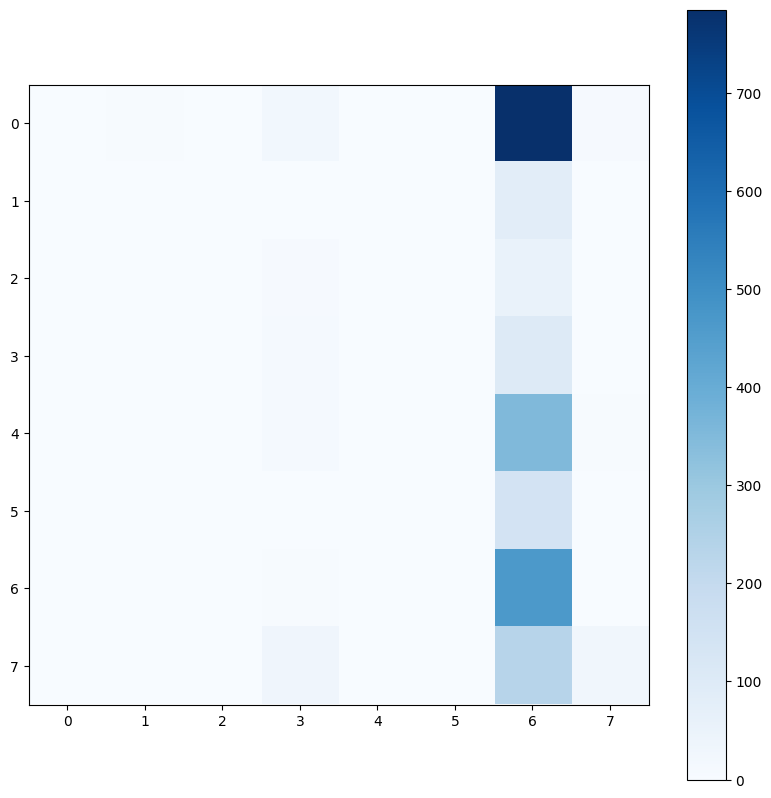

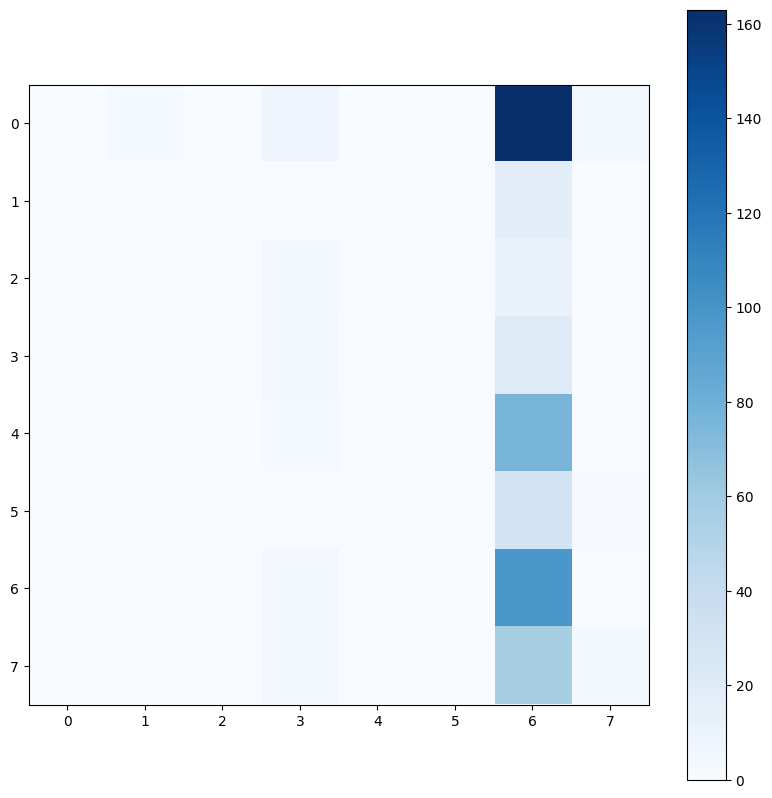

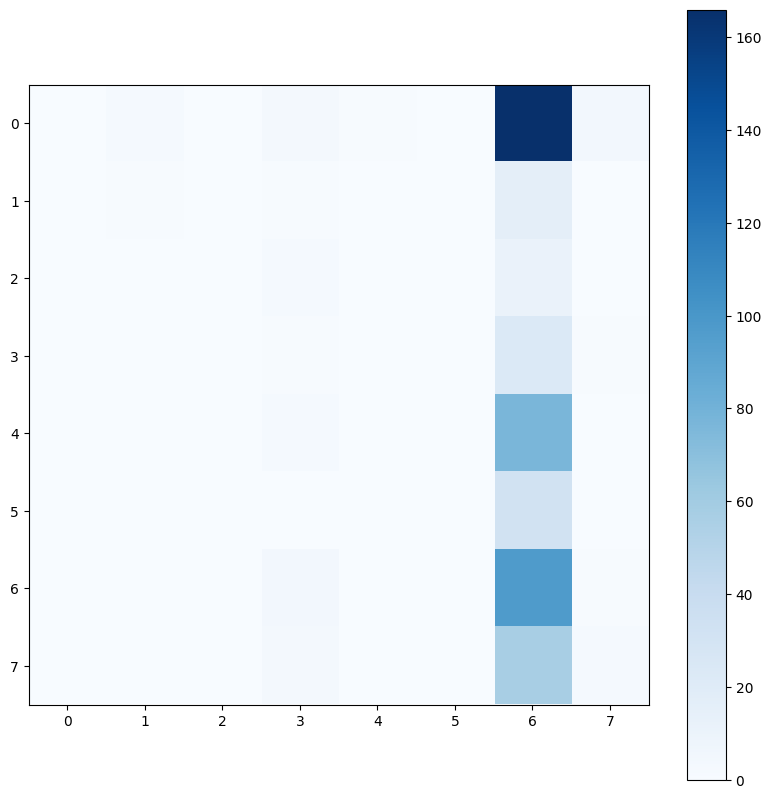

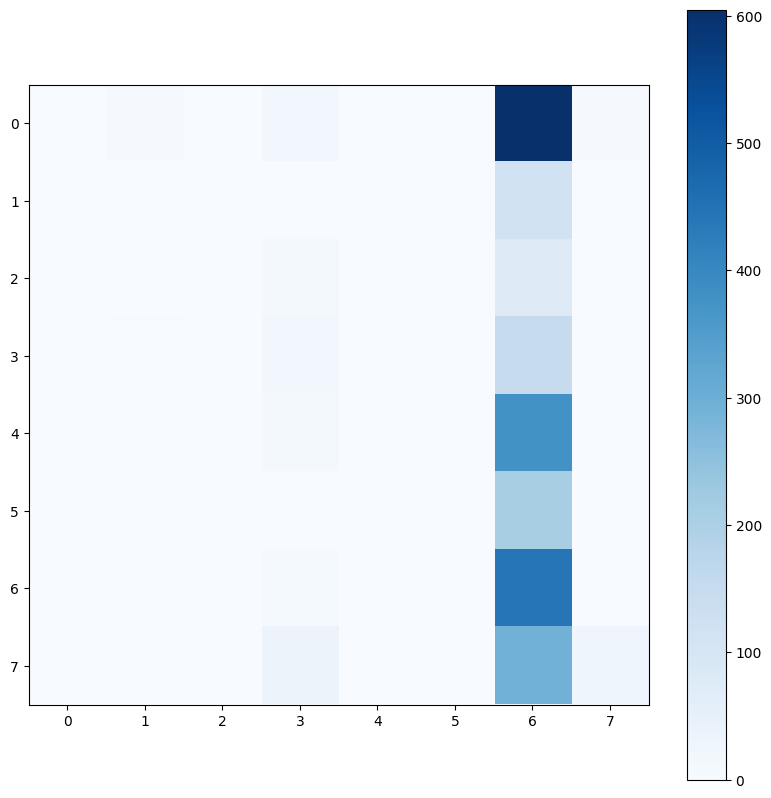

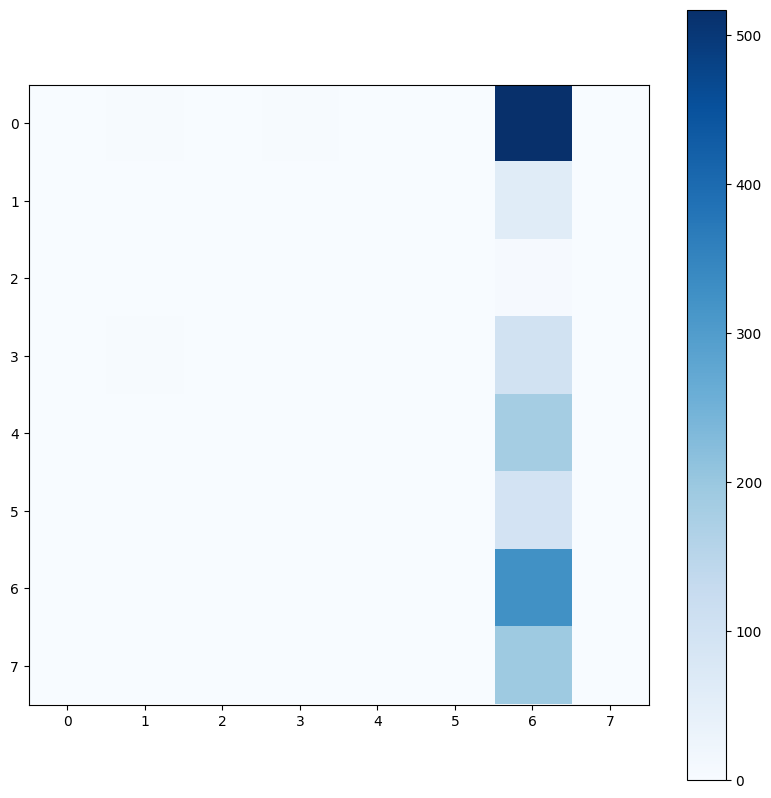

In [4]:
from e07_english_eval_common import run_english_eval_pipeline

# Optional: tune batch size if you hit OOM when you run later
summary = run_english_eval_pipeline(MODEL_RUN_ID, batch_size=16, max_length=128, seed=42)

list(summary["per_dataset"].keys())


## Key takeaways

- **One model, one directory:** all artifacts for this run live under `notebooks/results/english_eval/<MODEL_RUN_ID>/` and `figures/english_eval/<MODEL_RUN_ID>/`.
- **No shared mutable index** is updated across models (avoids parallel write races). Use `PLANNED_OUTPUTS.json` and each `run_manifest.json` to locate outputs.
- **Labels** are filtered to those present in the checkpoint’s `label_encoder`; rows with English-only classes the encoder never saw are **dropped** and counted in `metrics.json`.
